In [1]:
import itertools
import time
import random
import networkx as nx
import matplotlib.pyplot as plt

In [2]:
# Number of locations (including warehouse at index 0)
n = 5

# Distance matrix (symmetric for simplicity)
dist = [
    [0, 10, 15, 20, 25],
    [10, 0, 35, 25, 17],
    [15, 35, 0, 30, 28],
    [20, 25, 30, 0, 22],
    [25, 17, 28, 22, 0]
]

# Parcel data (value, weight, time window)
parcels = [
    {"id": 1, "value": 100, "weight": 5, "time": (1, 5)},
    {"id": 2, "value": 60, "weight": 3, "time": (2, 6)},
    {"id": 3, "value": 120, "weight": 7, "time": (3, 7)},
    {"id": 4, "value": 80, "weight": 4, "time": (1, 4)}
]

max_capacity = 10

In [4]:
def route_cost(path):
    cost = 0
    for i in range(len(path) - 1):
        cost += dist[path[i]][path[i+1]]
    return cost

def tsp_recursive(curr, visited):
    if len(visited) == n:
        return dist[curr][0]  # return to warehouse
    
    min_cost = float('inf')
    
    for i in range(n):
        if i not in visited:
            cost = dist[curr][i] + tsp_recursive(i, visited + [i])
            min_cost = min(min_cost, cost)
    
    return min_cost

print("Minimum route cost (recursive):", tsp_recursive(0, [0]))

Minimum route cost (recursive): 94


In [5]:
# Sort parcels based on value/weight ratio
parcels_sorted = sorted(parcels, key=lambda x: x["value"]/x["weight"], reverse=True)

selected = []
current_weight = 0

for p in parcels_sorted:
    if current_weight + p["weight"] <= max_capacity:
        selected.append(p)
        current_weight += p["weight"]

print("Selected Parcels:", selected)

Selected Parcels: [{'id': 1, 'value': 100, 'weight': 5, 'time': (1, 5)}, {'id': 2, 'value': 60, 'weight': 3, 'time': (2, 6)}]


In [6]:
def check_time(parcel):
    start, end = parcel["time"]
    return start <= 5 <= end  # assume delivery at time = 5

valid_parcels = [p for p in selected if check_time(p)]

print("Valid Parcels after time check:", valid_parcels) 

Valid Parcels after time check: [{'id': 1, 'value': 100, 'weight': 5, 'time': (1, 5)}, {'id': 2, 'value': 60, 'weight': 3, 'time': (2, 6)}]


In [7]:
G = nx.Graph()

for i in range(n):
    for j in range(i+1, n):
        G.add_edge(i, j, weight=dist[i][j])

shortest = nx.single_source_dijkstra_path_length(G, 0)

print("Shortest distances from warehouse:", shortest)

Shortest distances from warehouse: {0: 0, 1: 10, 2: 15, 3: 20, 4: 25}


In [8]:
mst = nx.minimum_spanning_tree(G)

print("MST edges:")
for edge in mst.edges(data=True):
    print(edge)

MST edges:
(0, 1, {'weight': 10})
(0, 2, {'weight': 15})
(0, 3, {'weight': 20})
(1, 4, {'weight': 17})


In [9]:
nodes = list(range(1, n))
min_path = None
min_cost = float('inf')

for perm in itertools.permutations(nodes):
    path = [0] + list(perm) + [0]
    cost = route_cost(path)
    
    if cost < min_cost:
        min_cost = cost
        min_path = path

print("Best Path:", min_path)
print("Minimum Cost:", min_cost)

Best Path: [0, 1, 4, 3, 2, 0]
Minimum Cost: 94


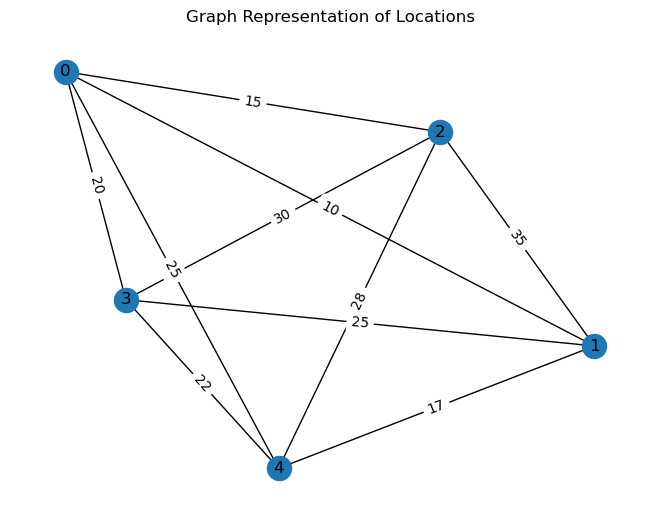

In [10]:
pos = nx.spring_layout(G)

plt.figure()
nx.draw(G, pos, with_labels=True)
nx.draw_networkx_edge_labels(G, pos, edge_labels=nx.get_edge_attributes(G,'weight'))

plt.title("Graph Representation of Locations")
plt.show()

In [11]:
start = time.time()
tsp_recursive(0, [0])
end = time.time()

print("Execution Time:", end - start)

Execution Time: 0.0008912086486816406
